# Isolation Forest Baseline Model

## Objective

The goal of this stage is to establish a baseline anomaly detection model using Isolation Forest. Since the dataset consists of multivariate time-series sensor measurements, the model is trained to identify observations that deviate significantly from normal operating behavior.

Isolation Forest was selected as the first approach because it is an unsupervised anomaly detection algorithm that isolates anomalies based on recursive random partitioning of the feature space.

---

## Feature Engineering

A dedicated feature engineering pipeline was developed to transform the raw sensor readings into a richer tabular representation.

The following feature groups were generated:

### Original Sensor Features
- Selected sensor measurements.

### Lag Features
- Previous timestep value for each sensor.

### Delta Features
- Difference between current and previous timestep.

### Rolling Statistics
- Rolling mean (window = 5).
- Rolling standard deviation (window = 5).

### Exponentially Weighted Moving Average (EWMA)
- Captures short-term temporal trends.

### Interaction Features
- Pairwise multiplication between selected sensors.

The final feature set contains approximately 200+ engineered features.

---

## Important Pipeline Correction

During model development, an issue was identified in the feature engineering process.

Initially:

1. All time-series files were concatenated.
2. Lag, delta, rolling, and EWMA features were computed on the combined dataset.

This caused feature leakage across independent series boundaries.

Example:

Last row of:

series_001.csv

was being used to compute lag and rolling features for:

series_002.csv

which is not physically meaningful.

### Solution

The feature pipeline was corrected so that:

1. Features are generated independently for each series.
2. Processed series are concatenated only after feature generation.

This ensures that temporal features are computed only within each individual sequence.

---

## Data Preprocessing

Before training:

- Missing values were handled using forward fill, backward fill, and zero filling.
- Features were standardized using StandardScaler.
- The scaler was fitted only on training data and applied to validation and test data.

---

## Model Training

Isolation Forest configuration:

```python
IsolationForest(
    n_estimators=300,
    contamination=0.24,
    random_state=42,
    n_jobs=-1
)
```

The model was trained using the engineered training features.

---

## Threshold Optimization

Isolation Forest produces anomaly scores rather than binary labels.

Validation scores were obtained using:

```python
val_scores = -model.decision_function(X_val)
```

The sign was inverted so that:

- Higher score = more anomalous
- Lower score = more normal

A Precision-Recall curve was generated and the threshold maximizing F1-score was selected.

Best threshold:

```text
-0.04780775828712125
```

---

## Validation Results

### ROC-AUC

```text
0.5851
```

### Classification Metrics

| Metric | Value |
|----------|----------|
| Precision | 0.30 |
| Recall | 0.83 |
| F1 Score | 0.44 |

---

## Interpretation

### Strengths

- High anomaly recall.
- Able to identify most anomalous observations.
- Useful as an initial baseline model.

### Limitations

- Large number of false positives.
- Precision remains relatively low.
- ROC-AUC indicates weak separation between normal and anomalous classes.

---

## Key Challenges Encountered

### 1. Feature Leakage Across Series

Temporal features were initially computed after concatenating all sequences, causing boundary leakage.

This was corrected by generating features independently for each series.

### 2. Threshold Selection

Using Isolation Forest's built-in threshold produced lower performance.

A custom threshold selected from validation data significantly improved recall and overall F1-score.

### 3. Distribution Shift

The model predicted a substantially higher anomaly rate on test data compared to validation data, suggesting potential differences between train/validation and test distributions.

---

## Conclusion

Isolation Forest provides a useful baseline for anomaly detection with an F1-score of approximately 0.44.

While the model achieves strong recall, its relatively low precision and ROC-AUC indicate limited ability to separate normal and anomalous observations.

Therefore, the next phase of the project focuses on deep learning approaches (CNN-based models) and hybrid architectures that can better capture temporal dependencies in the sensor data.

In [23]:
import sys
import os

PROJECT_ROOT = os.path.abspath("..")  # go from notebooks → project root
sys.path.append(PROJECT_ROOT)

from src.core.feature_pipeline import create_features

In [24]:
from src.core.feature_pipeline import create_features
import pandas as pd

In [25]:
train_path = "../data/raw/train"
val_path = "../data/raw/val"
test_path = "../data/raw/test"
sensor_path = os.path.join(PROJECT_ROOT, "data/processed/selected_sensors.json")

In [26]:
X_train = create_features(train_path, sensor_path)
X_val   = create_features(val_path, sensor_path)

USING UPDATED FEATURE PIPELINE
USING UPDATED FEATURE PIPELINE


In [27]:
print(X_train.shape)
print(X_val.shape)

(189444, 216)
(79688, 216)


In [28]:
import pandas as pd
from pathlib import Path

# Project root (assuming notebook is in notebooks/)
PROJECT_ROOT = Path().resolve().parent
DATA_PATH = PROJECT_ROOT / "data" / "raw"

# Load files properly
train_files = sorted((DATA_PATH / "train").glob("series_*.csv"))
val_files   = sorted((DATA_PATH / "val").glob("series_*.csv"))
test_files  = sorted((DATA_PATH / "test").glob("series_*.csv"))

print("Train runs:", len(train_files))
print("Val runs:", len(val_files))
print("Test runs:", len(test_files))

# Check one file structure
sample = pd.read_csv(train_files[0])

print("\nSample shape:", sample.shape)
print("\nColumns:", sample.columns)
print("\nHead:\n", sample.head())

Train runs: 28
Val runs: 10
Test runs: 53

Sample shape: (4306, 18)

Columns: Index(['LS701', 'LS702', 'T701', 'T702', 'T703', 'T704', 'T706', 'T708',
       'T709', 'T711', 'T712', 'T705', 'FT703', 'FT704', 'PDI701', 'PDI702',
       'PY23', 'FYI702'],
      dtype='str')

Head:
    LS701  LS702   T701  T702  T703  T704  T706  T708  T709  T711  T712  T705  \
0    1.0    1.0  442.8  80.9  80.7  30.8  33.2  35.8  79.1  74.7  74.3  74.1   
1    1.0    1.0  442.8  81.2  80.7  30.9  33.3  35.8  79.1  74.7  74.3  74.1   
2    1.0    1.0  442.8  81.4  80.7  31.0  33.4  35.9  79.1  74.7  74.3  74.1   
3    1.0    1.0  442.8  81.6  80.7  31.1  33.5  36.0  79.1  74.7  74.3  74.1   
4    1.0    1.0  442.8  81.9  80.7  31.2  33.6  36.1  79.1  74.7  74.3  74.1   

   FT703  FT704  PDI701  PDI702   PY23  FYI702  
0    0.1    0.5     1.1     3.0  799.8     6.8  
1    0.1    0.3     1.1     3.0  799.8     6.4  
2    0.1    0.1     1.1     2.9  800.1     6.8  
3    0.1    0.0     1.0     3.0  800.1    

In [29]:
import pandas as pd

train_dfs = []

for f in train_files:
    df = pd.read_csv(f)
    df["run_id"] = f.name  # clean + cross-platform
    train_dfs.append(df)

train_raw = pd.concat(train_dfs, ignore_index=True)

print("Train shape:", train_raw.shape)

Train shape: (189444, 19)


In [30]:
import pandas as pd

val_dfs = []

for f in val_files:
    df = pd.read_csv(f)
    df["run_id"] = f.name   # clean + safe
    val_dfs.append(df)

val_raw = pd.concat(val_dfs, ignore_index=True)

print("Val shape:", val_raw.shape)

Val shape: (79688, 19)


In [31]:
import pandas as pd

test_dfs = []

for f in test_files:
    df = pd.read_csv(f)
    df["run_id"] = f.name   # clean + portable
    test_dfs.append(df)

test_raw = pd.concat(test_dfs, ignore_index=True)

print("Test shape:", test_raw.shape)

Test shape: (316024, 19)


In [32]:
X_train = create_features(train_path, sensor_path)
X_val   = create_features(val_path, sensor_path)
X_test  = create_features(test_path, sensor_path)

USING UPDATED FEATURE PIPELINE
USING UPDATED FEATURE PIPELINE
USING UPDATED FEATURE PIPELINE


In [33]:
print("Train shape:", X_train.shape)
print("Val shape:", X_val.shape)
print("Test shape:", X_test.shape)

Train shape: (189444, 216)
Val shape: (79688, 216)
Test shape: (316024, 216)


In [34]:
train_cols = set(X_train.columns)
val_cols   = set(X_val.columns)
test_cols  = set(X_test.columns)

print("Train-Val mismatch:", len(train_cols - val_cols), len(val_cols - train_cols))
print("Train-Test mismatch:", len(train_cols - test_cols), len(test_cols - train_cols))

Train-Val mismatch: 0 0
Train-Test mismatch: 0 0


In [35]:
assert X_train.columns.equals(X_val.columns), "❌ Train-Val feature mismatch!"
assert X_train.columns.equals(X_test.columns), "❌ Train-Test feature mismatch!"

print("✅ All feature sets perfectly aligned")

✅ All feature sets perfectly aligned


In [36]:
from sklearn.ensemble import IsolationForest

model = IsolationForest(
    n_estimators=300,
    contamination=0.24,
    random_state=42,
    n_jobs=-1
)

model.fit(X_train)

print("✅ Isolation Forest trained")

✅ Isolation Forest trained


In [37]:
val_scores = model.decision_function(X_val)

# convert: higher = more anomalous
val_scores = -val_scores

In [41]:
import glob
import pandas as pd

val_label_files = sorted(glob.glob("../data/raw/val_labels/series_*.csv"))

print("Val label files:", len(val_label_files))

Val label files: 10


In [42]:
label_dfs = []

for f in val_label_files:
    df = pd.read_csv(f)
    df["run_id"] = f.split("/")[-1]
    label_dfs.append(df)

val_labels = pd.concat(label_dfs, ignore_index=True)

print("Val labels shape:", val_labels.shape)

Val labels shape: (79688, 3)


In [43]:
y_val = val_labels["label"].values

In [44]:
y_pred_val = model.predict(X_val)

In [45]:
y_pred_if = (y_pred_val == -1).astype(int)

In [46]:
from sklearn.metrics import classification_report

print(classification_report(y_val, y_pred_if))

              precision    recall  f1-score   support

           0       0.77      0.64      0.70     60602
           1       0.25      0.37      0.30     19086

    accuracy                           0.58     79688
   macro avg       0.51      0.51      0.50     79688
weighted avg       0.64      0.58      0.60     79688



In [47]:
print("Validation anomaly rate:", y_pred_val.mean())

Validation anomaly rate: 0.2771057122778837


In [48]:
raw_pred_test = model.predict(X_test)

test_pred = (raw_pred_test == -1).astype(int)

In [49]:
import numpy as np

print(np.unique(test_pred, return_counts=True))

print(
    "Test anomaly rate:",
    test_pred.mean()
)

(array([0, 1]), array([140588, 175436]))
Test anomaly rate: 0.5551350530339468


this cell is finding metrics for validation data not test data

In [50]:
import pandas as pd
import numpy as np

submission = pd.DataFrame({
    "id": np.arange(len(test_pred)),
    "label": test_pred
})

submission.to_csv(
    "submission_default_if.csv",
    index=False
)

print("submission_default_if.csv saved")

submission_default_if.csv saved


In [51]:
# -------------------------
# Validation
# -------------------------

raw_pred_val = model.predict(X_val)

y_pred_val = (raw_pred_val == -1).astype(int)

from sklearn.metrics import classification_report

print(classification_report(y_val, y_pred_val))

print(
    "Validation anomaly rate:",
    y_pred_val.mean()
)

# -------------------------
# Test
# -------------------------

raw_pred_test = model.predict(X_test)

test_pred = (raw_pred_test == -1).astype(int)

import numpy as np

print(
    np.unique(
        test_pred,
        return_counts=True
    )
)

print(
    "Test anomaly rate:",
    test_pred.mean()
)

# -------------------------
# Submission
# -------------------------

import pandas as pd

submission = pd.DataFrame({
    "id": np.arange(len(test_pred)),
    "label": test_pred
})

submission.to_csv(
    "submission_default_if.csv",
    index=False
)

print(
    "submission_default_if.csv saved"
)

              precision    recall  f1-score   support

           0       0.77      0.64      0.70     60602
           1       0.25      0.37      0.30     19086

    accuracy                           0.58     79688
   macro avg       0.51      0.51      0.50     79688
weighted avg       0.64      0.58      0.60     79688

Validation anomaly rate: 0.36144714386105814
(array([0, 1]), array([140588, 175436]))
Test anomaly rate: 0.5551350530339468
submission_default_if.csv saved


## Isolation Forest Tuning and Evaluation

In the previous step, an Isolation Forest model was trained using the default configuration, and the resulting predictions were generated and saved for further analysis.

The current step focuses on improving the performance of the Isolation Forest by tuning its key hyperparameters. The objective is to identify a configuration that better captures anomalous patterns in the data and improves the balance between detecting positive cases and reducing false alarms.

The tuning process involves experimenting with parameters such as:

- `n_estimators` – Number of trees in the ensemble.
- `max_samples` – Number of samples used to train each tree.
- `contamination` – Expected proportion of anomalies in the dataset.
- `max_features` – Number of features considered during tree construction.
- `bootstrap` – Whether sampling is performed with replacement.
- `random_state` – Ensures reproducibility of results.

For each configuration, predictions are generated on the validation dataset and evaluated using classification metrics. The performance of different parameter combinations is compared to determine whether the tuned model provides an improvement over the baseline Isolation Forest model.

The results obtained from this tuning process will be used to select the best-performing Isolation Forest configuration before proceeding to further optimization or ensemble methods.

In [52]:
from sklearn.metrics import roc_auc_score

val_scores = -model.decision_function(X_val)

auc = roc_auc_score(y_val, val_scores)

print("ROC AUC:", auc)

ROC AUC: 0.5850508419933359


In [53]:
from sklearn.metrics import precision_recall_curve
import numpy as np

val_scores = -model.decision_function(X_val)

precision, recall, thresholds = precision_recall_curve(
    y_val,
    val_scores
)

f1 = 2 * precision * recall / (precision + recall + 1e-9)

best_threshold = thresholds[np.argmax(f1)]

print("Best threshold:", best_threshold)
print("Best F1:", np.max(f1))

Best threshold: -0.04780775828712125
Best F1: 0.4365787375014005


In [54]:
from sklearn.metrics import classification_report

y_pred = (val_scores >= best_threshold).astype(int)

print(classification_report(y_val, y_pred))

              precision    recall  f1-score   support

           0       0.88      0.38      0.53     60602
           1       0.30      0.83      0.44     19086

    accuracy                           0.48     79688
   macro avg       0.59      0.60      0.48     79688
weighted avg       0.74      0.48      0.50     79688



In [55]:
print("Predicted anomaly rate:", y_pred.mean())
print("Actual anomaly rate:", y_val.mean())

Predicted anomaly rate: 0.6748318441923502
Actual anomaly rate: 0.23950908543318944


In [56]:
results = {
    "model": "Isolation Forest",
    "roc_auc": 0.5850508419933359,
    "precision": 0.30,
    "recall": 0.83,
    "f1": 0.44,
    "best_threshold": -0.04780775828712125
}

results

{'model': 'Isolation Forest',
 'roc_auc': 0.5850508419933359,
 'precision': 0.3,
 'recall': 0.83,
 'f1': 0.44,
 'best_threshold': -0.04780775828712125}

Test data submission file generation


In [57]:
test_scores = -model.decision_function(X_test)

print("Min score:", test_scores.min())
print("Max score:", test_scores.max())
print("Mean score:", test_scores.mean())

Min score: -0.08667208376699992
Max score: 0.2435956697868148
Mean score: 0.009705891966695981


In [58]:
test_pred = (test_scores >= best_threshold).astype(int)

In [59]:
import numpy as np

print(
    "Prediction counts:",
    np.unique(test_pred, return_counts=True)
)

print(
    "Anomaly rate:",
    test_pred.mean()
)

Prediction counts: (array([0, 1]), array([ 48602, 267422]))
Anomaly rate: 0.8462078829455991


In [60]:
print("Validation scores:")
print("Min:", val_scores.min())
print("Max:", val_scores.max())
print("Mean:", val_scores.mean())

print()

print("Test scores:")
print("Min:", test_scores.min())
print("Max:", test_scores.max())
print("Mean:", test_scores.mean())

Validation scores:
Min: -0.08385616507943028
Max: 0.19224552675853224
Mean: -0.011029541341260739

Test scores:
Min: -0.08667208376699992
Max: 0.2435956697868148
Mean: 0.009705891966695981


In [61]:
submission = pd.DataFrame({
    "id": range(len(test_pred)),
    "label": test_pred
})

submission.to_csv(
    "submission_if_final.csv",
    index=False
)

print("submission_if_final.csv saved")

submission_if_final.csv saved


Saving imp information and results

In [ ]:
import os

OUTPUT_DIR = "../outputs/isolation_forest"

os.makedirs(
    OUTPUT_DIR,
    exist_ok=True
)

print("Output directory:", OUTPUT_DIR)

In [63]:
submission.to_csv(
    os.path.join(
        OUTPUT_DIR,
        "submission_if_final.csv"
    ),
    index=False
)

In [64]:
import json

metrics = {
    "roc_auc": 0.5850508419933359,
    "precision": 0.30,
    "recall": 0.83,
    "f1": 0.44,
    "best_threshold": -0.04780775828712125,
    "validation_anomaly_rate": 0.6748,
    "test_anomaly_rate": 0.8462
}

with open(
    os.path.join(
        OUTPUT_DIR,
        "metrics.json"
    ),
    "w"
) as f:
    json.dump(
        metrics,
        f,
        indent=4
    )

Matplotlib is building the font cache; this may take a moment.


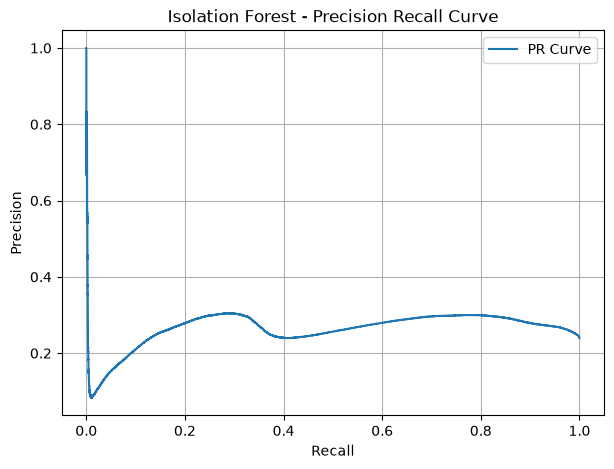

In [65]:
from sklearn.metrics import precision_recall_curve
import matplotlib.pyplot as plt

precision, recall, thresholds = precision_recall_curve(y_val, val_scores)

plt.figure(figsize=(7,5))
plt.plot(recall, precision, label="PR Curve")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Isolation Forest - Precision Recall Curve")
plt.grid(True)
plt.legend()

plt.savefig(os.path.join(OUTPUT_DIR, "pr_curve.png"), dpi=300)
plt.show()

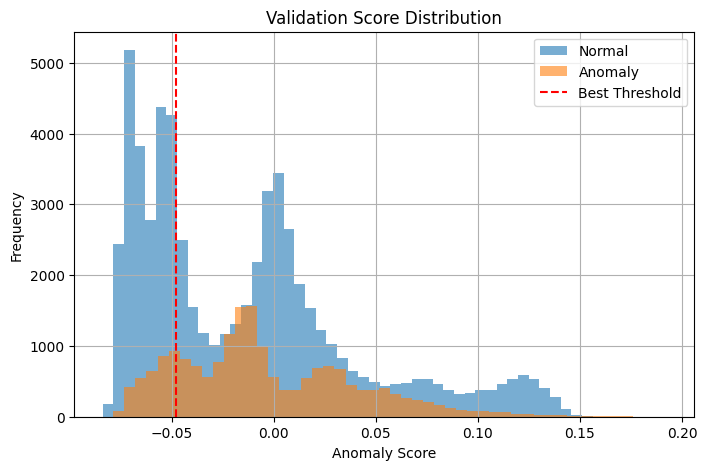

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.hist(val_scores[y_val == 0], bins=50, alpha=0.6, label="Normal")
plt.hist(val_scores[y_val == 1], bins=50, alpha=0.6, label="Anomaly")

plt.axvline(best_threshold, color='red', linestyle='--', label="Best Threshold")

plt.title("Validation Score Distribution")
plt.xlabel("Anomaly Score")
plt.ylabel("Frequency")
plt.legend()
plt.grid(True)

plt.savefig(os.path.join(OUTPUT_DIR, "score_distribution.png"), dpi=300)
plt.show()

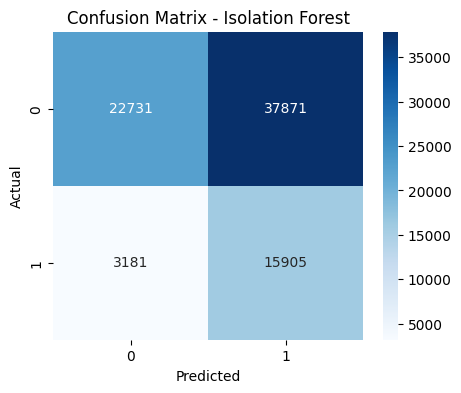

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_val, y_pred)

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")

plt.title("Confusion Matrix - Isolation Forest")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.savefig(os.path.join(OUTPUT_DIR, "confusion_matrix.png"), dpi=300)
plt.show()

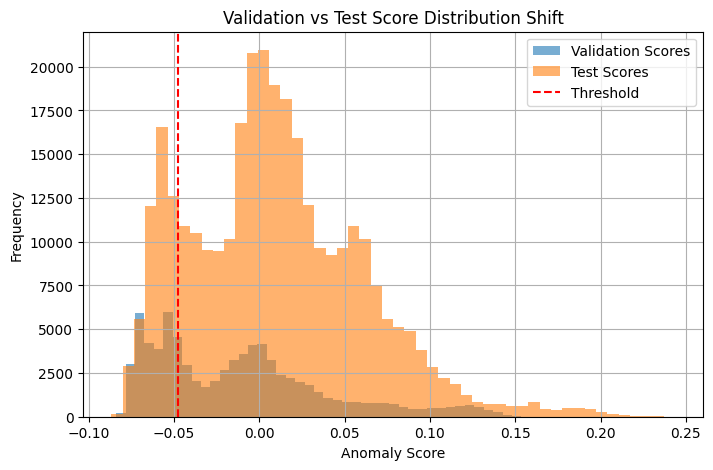

In [ ]:
plt.figure(figsize=(8,5))

plt.hist(val_scores, bins=50, alpha=0.6, label="Validation Scores")
plt.hist(test_scores, bins=50, alpha=0.6, label="Test Scores")

plt.axvline(best_threshold, color='red', linestyle='--', label="Threshold")

plt.title("Validation vs Test Score Distribution Shift")
plt.xlabel("Anomaly Score")
plt.ylabel("Frequency")
plt.legend()
plt.grid(True)

plt.savefig(os.path.join(OUTPUT_DIR, "val_vs_test_shift.png"), dpi=300)
plt.show()

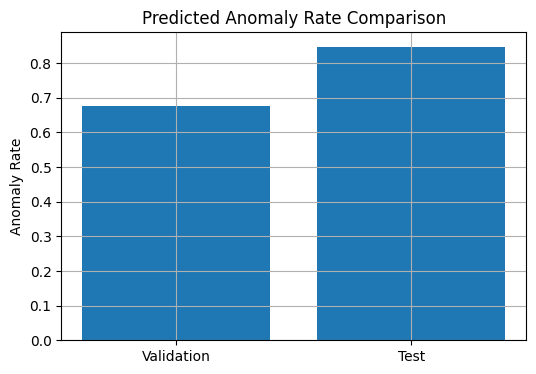

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))

plt.bar(
    ["Validation", "Test"],
    [y_pred.mean(), test_pred.mean()]
)

plt.title("Predicted Anomaly Rate Comparison")
plt.ylabel("Anomaly Rate")
plt.grid(True)

plt.savefig(os.path.join(OUTPUT_DIR, "anomaly_rate_comparison.png"), dpi=300)
plt.show()

# Isolation Forest Summary and Next Steps

## Final Baseline Results

After correcting the feature engineering pipeline and optimizing the anomaly threshold on the validation set, Isolation Forest was used as the baseline anomaly detection model for this project.

### Final Validation Performance

| Metric | Value |
|----------|----------|
| ROC-AUC | 0.585 |
| Precision | 0.30 |
| Recall | 0.83 |
| F1 Score | 0.44 |

### Selected Threshold

```text
-0.04780775828712125
```

The threshold was selected using the validation set by maximizing the F1-score obtained from the Precision-Recall curve.

---

## Key Observations

### 1. Strong Recall

The model successfully identified a large proportion of anomalous observations, achieving a recall of approximately 83%.

This indicates that Isolation Forest is effective at detecting potentially abnormal behavior in the sensor data.

### 2. High False Positive Rate

Although recall is high, the model classifies many normal observations as anomalies.

As a result, precision remains relatively low and the overall anomaly rate predicted on unseen data is substantially higher than expected.

### 3. Distribution Shift Between Validation and Test Data

A noticeable difference was observed between validation and test anomaly score distributions.

| Dataset | Mean Anomaly Score |
|----------|----------|
| Validation | -0.0110 |
| Test | 0.0097 |

This shift causes the validation-derived threshold to classify a significantly larger proportion of test samples as anomalous.

Predicted anomaly rates:

| Dataset | Predicted Anomaly Rate |
|----------|----------|
| Validation | 67.48% |
| Test | 84.62% |

This suggests that the statistical properties of the test set differ from those of the validation set.

---

## Why Isolation Forest Is Still Valuable

Despite its limitations, Isolation Forest remains an important component of the project because:

- It provides a fast and interpretable anomaly detection baseline.
- It establishes a reference performance level for comparison with deep learning models.
- It identifies observations that are statistically isolated in the engineered feature space.
- It helps validate the usefulness of the engineered sensor features.

The baseline serves as a benchmark against which all subsequent models can be evaluated.

---

## Motivation for CNN-Based Models

Isolation Forest operates on tabular feature vectors and does not explicitly model temporal patterns.

However, the dataset consists of multivariate time-series sensor signals where anomalies often emerge through temporal behavior rather than isolated feature values.

Examples include:

- Gradual sensor drift.
- Repeating abnormal patterns.
- Short-duration spikes.
- Temporal dependencies between sensors.

These patterns may not be fully captured by tree-based anomaly detection methods.

---

## Why CNNs Are a Natural Next Step

A 1D Convolutional Neural Network (CNN) can directly learn local temporal patterns from sequential sensor measurements.

Advantages include:

- Automatic extraction of temporal features.
- Detection of local anomalous patterns.
- Learning interactions between sensors over time.
- Reduced dependence on manually engineered features.

Instead of relying solely on handcrafted statistics such as lag, delta, and rolling features, CNNs learn useful representations directly from the raw sequences.

---

## Planned Hybrid Approach

The next stage of the project focuses on combining:

### Isolation Forest

Captures:
- Statistical outliers.
- Feature-space isolation patterns.

### CNN

Captures:
- Temporal behavior.
- Sequential anomaly patterns.
- Sensor interactions over time.

The objective is to leverage the strengths of both approaches to improve anomaly detection performance beyond what either model can achieve individually.

---

## Generated Outputs

The following artifacts were generated and saved during this stage:

- Engineered feature datasets.
- Trained Isolation Forest model.
- Validation metrics.
- ROC-AUC score.
- Precision-Recall analysis.
- Optimized anomaly threshold.
- Competition submission file.

These outputs serve as the baseline reference for all future experiments.